# Badminton Court Homography — Player Simulation

In [85]:
import importlib
import homography_engine
importlib.reload(homography_engine)          # always reload so edits take effect
from homography_engine import CourtHomographyEngine

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('All imports OK')

All imports OK


In [94]:

COURT_MODEL_PATH  = r"E:\badminton prj\Z coor\runs\pose\train3\weights\best.pt"
PLAYER_MODEL_PATH = r"E:\badminton prj\badminton-court-detection-4\runs\detect\train5\weights\best.pt"
IMAGE_PATH        = r"E:\badminton prj\Z coor\yolo\test\images\Men-s-Singles-_-Jonatan-Christie-INA-vs_-Lakshya-Sen-IND-_-Badminton-2026_mp4-0063_jpg.rf.2d0b09dc8819d9d311a60adfce2fecf9.jpg"

court_model  = YOLO(COURT_MODEL_PATH)
player_model = YOLO(PLAYER_MODEL_PATH)


In [95]:
image = cv2.imread(IMAGE_PATH)
assert image is not None, f'Cannot read image: {IMAGE_PATH}'

court_result  = court_model(image)[0]
player_result = player_model(image)[0]

print(f'Court  detections : {len(court_result.keypoints.xy)}')
print(f'Player detections : {len(player_result.boxes)}')


0: 384x640 1 court, 62.3ms
Speed: 34.6ms preprocess, 62.3ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 players, 8.9ms
Speed: 1.5ms preprocess, 8.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Court  detections : 1
Player detections : 3


In [96]:

all_kps = court_result.keypoints.xy[0].cpu().numpy()
print('All court keypoints:')
for i, (x, y) in enumerate(all_kps):
    print(f'  kp[{i}]: ({x:.1f}, {y:.1f})')

All court keypoints:
  kp[0]: (619.0, 552.9)
  kp[1]: (389.9, 1028.1)
  kp[2]: (1641.1, 1037.6)
  kp[3]: (1437.9, 559.8)
  kp[4]: (527.4, 508.8)
  kp[5]: (541.6, 751.5)
  kp[6]: (1522.5, 511.2)
  kp[7]: (1519.9, 752.3)


In [97]:

court_kps = all_kps[[0, 3, 2, 1]]   

print('Reordered court corners:')
for label, (x, y) in zip(['TL','TR','BR','BL'], court_kps):
    print(f'  {label}: ({x:.1f}, {y:.1f})')

Reordered court corners:
  TL: (619.0, 552.9)
  TR: (1437.9, 559.8)
  BR: (1641.1, 1037.6)
  BL: (389.9, 1028.1)


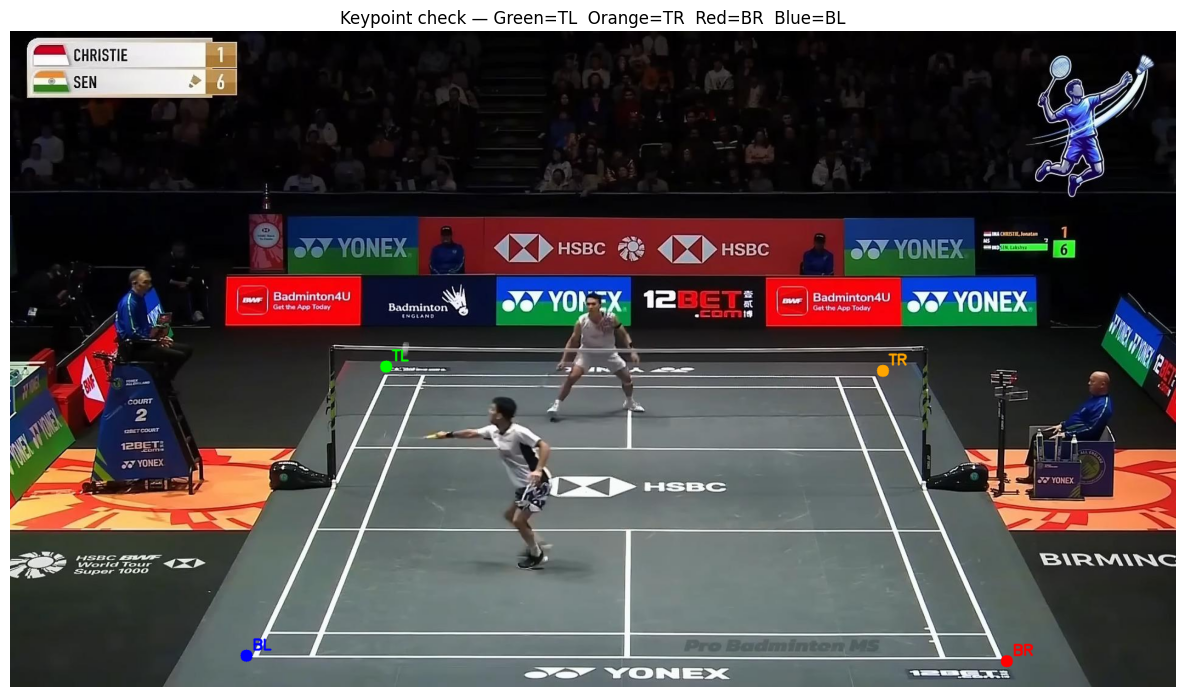

In [98]:

engine    = CourtHomographyEngine(court_width=6.1, court_length=13.4, scale=100)
debug_img = engine.debug_keypoint_order(image, court_kps)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
plt.title('Keypoint check — Green=TL  Orange=TR  Red=BR  Blue=BL', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

In [99]:

player_points = []
for box in player_result.boxes.xyxy:
    x1, y1, x2, y2 = box.cpu().numpy()
    player_points.append([(x1 + x2) / 2, y2])

print(f'{len(player_points)} players detected:')
for i, (x, y) in enumerate(player_points):
    print(f'  P{i+1} foot: ({x:.1f}, {y:.1f})')

3 players detected:
  P1 foot: (959.4, 644.6)
  P2 foot: (792.3, 893.0)
  P3 foot: (841.8, 893.8)


In [100]:
H = engine.compute_homography(court_kps)

print('Homography matrix H:')
print(np.round(H, 5))

projected_players = engine.project_points(player_points, H)

print(f'\nProjected positions on court board (scale={engine.scale}):')
for i, (px, py) in enumerate(projected_players):
    print(f'  P{i+1}: ({px:.1f}, {py:.1f}) px  →  ({px/engine.scale:.2f}m, {py/engine.scale:.2f}m)')

Homography matrix H:
[[    0.01875     0.00904     -16.606]
 [   -0.00092     0.10867     -59.521]
 [     -3e-05      0.0028           1]]

Projected positions on court board (scale=100):
  P1: (259.6, 347.3) px  →  (2.60m, 3.47m)
  P2: (181.8, 1057.7) px  →  (1.82m, 10.58m)
  P3: (208.6, 1058.5) px  →  (2.09m, 10.59m)


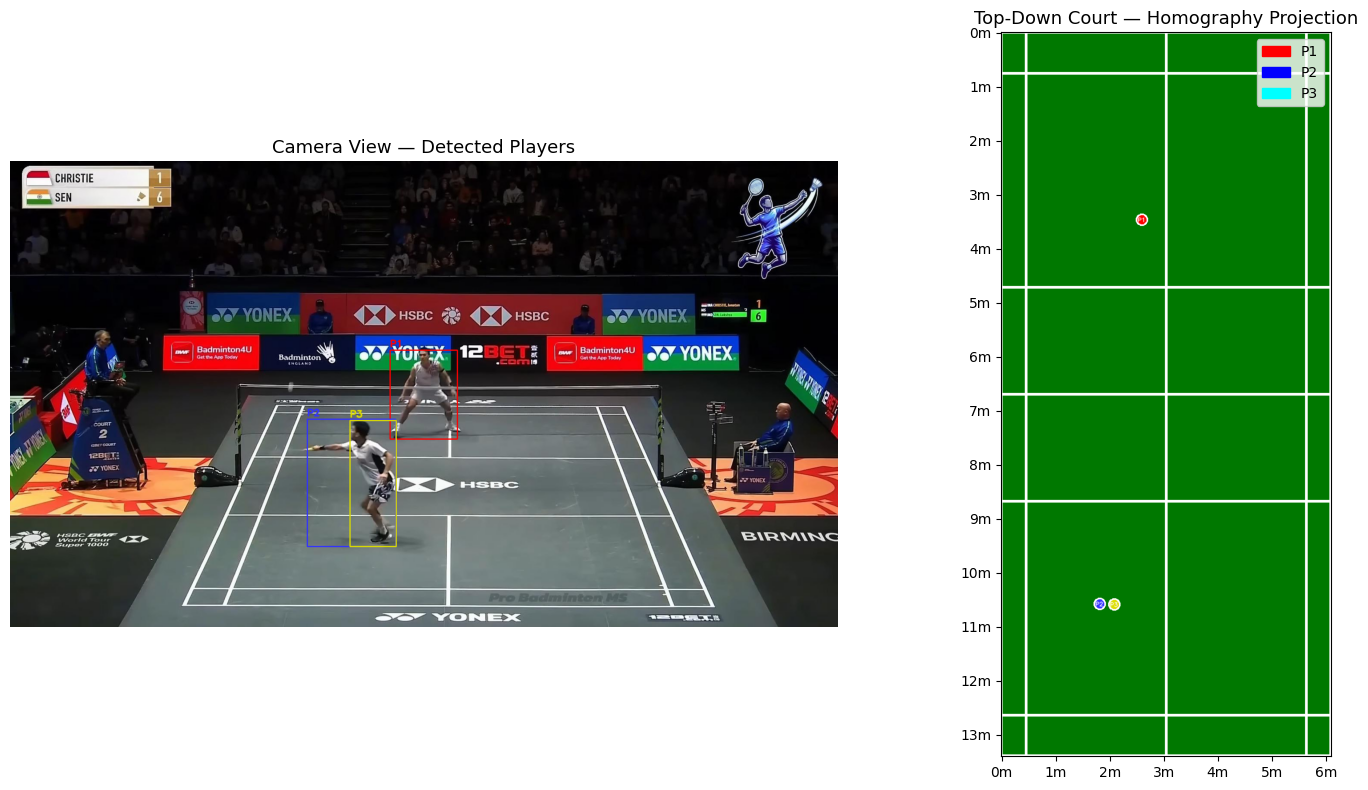

In [101]:

board = engine.create_court_board()
board = engine.draw_players(board, projected_players)

orig = image.copy()
bbox_colors = [(0,0,255),(255,50,50),(0,220,220),(200,0,200)]
for i, box in enumerate(player_result.boxes.xyxy):
    x1, y1, x2, y2 = [int(v) for v in box.cpu().numpy()]
    c = bbox_colors[i % len(bbox_colors)]
    cv2.rectangle(orig, (x1, y1), (x2, y2), c, 2)
    cv2.putText(orig, f'P{i+1}', (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, c, 2, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0].set_title('Camera View — Detected Players', fontsize=13)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(board, cv2.COLOR_BGR2RGB))
axes[1].set_title('Top-Down Court — Homography Projection', fontsize=13)

# Metre axis ticks
w_px = int(engine.court_width  * engine.scale)
h_px = int(engine.court_length * engine.scale)
xt = np.arange(0, w_px + 1, engine.scale)
yt = np.arange(0, h_px + 1, engine.scale)
axes[1].set_xticks(xt);  axes[1].set_xticklabels([f'{v/engine.scale:.0f}m' for v in xt])
axes[1].set_yticks(yt);  axes[1].set_yticklabels([f'{v/engine.scale:.0f}m' for v in yt])

# Legend
legend_colors = ['red','blue','cyan','magenta']
patches = [mpatches.Patch(color=legend_colors[i], label=f'P{i+1}')
           for i in range(len(player_points))]
axes[1].legend(handles=patches, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()